# Required Functions

In [1]:
import seaborn as sns
from matplotlib import pyplot as plt
from matplotlib.pyplot import pie,axis,show
%matplotlib inline

In [2]:
import pandas as pd
import json
import re
def load_dataframe(filename):
    with open(filename,'r') as f:
        df = pd.DataFrame(json.load(f))
        df['index'] = range(len(df))
        return df

def drop_cols(df,dropcols):
    return df[list(filter(lambda x:not re.search('|'.join(dropcols),x) ,df.columns))]

def plot_pie_chart(df,dropcols,dropre=['min','max','avg'],count=None):
    df = df.drop(dropcols,axis=1)
    df = drop_cols(df,dropre)
    count = len(df) if count is None else count
    for i in range(count):
        dfi = df.loc[str(i),:]
        axis('equal')
        labels = [ '-'.join(list(map(str,item))) for item in list(dfi.items())]
        pie(dfi, labels=labels,startangle=0)
        show()

def plot_pie_chart_(df,dropcols,dropre=['min','max','avg'],count=None,figdim=10):
    df = df.drop(dropcols,axis=1)
    df = drop_cols(df,dropre)
    count = len(df) if count is None else count
    rows = max(int(count/2),1)
    cols = 2 if count>1 else 1
    figsize = tuple([ figdim*rows for _ in range(rows) ])
    fig, ax = plt.subplots(rows,cols,figsize=figsize)
        
    for i in range(count):
        dfi = df.loc[str(i),:]
        ax = fig.add_subplot(rows,cols,(i%cols)+1)
        labels = [ '-'.join(list(map(str,item))) for item in list(dfi.items())]
        _, _ = ax.pie(dft.loc['0',:], startangle=0,labels=labels)
        ax.axis('equal')

def list_detections(output):
    dets_d = {}
    for ko in output.keys():
        d = output[ko]
        dets = []
        for k in d.keys():
            dc = d[k]
            dets.append(dc['output']['labels_detected'])
        dets_d[ko]=dets
    return dets_d

def count_elems(dct):
    count = {}
    sums = {}
    for k in dct.keys():
        count[k] = list(map(lambda l:len(l) ,dct[k]))
        sums[k] = sum(count[k])
    return count,sums

def read_dict(jsonfile):
    op = {}
    with open(jsonfile,'r') as f:
        op = json.load(f)
    return op

def get_intervals_data():
    its = list(map(read_dict,intervals_dicts))
    return its

def get_info_what_key(dct,key):
    for i in dct.keys():
        d = dct[i]
        for k in d.keys():
            if d[k]['key']==key:
                return k

def get_int_info(dct):
    res = {}
    for i in dct.keys():
        d = dct[i]
        res[i]={}
        for k in d.keys():
            key = d[k]['key']
            res[i][key]=d[k]['info']
            #res[i][key]['what']=k
    return res

def info_det(dct):
    res = {}
    for i in dct.keys():
        res[i] = dct[i]['detect']
    return res

# Fetch & Load Data

In [3]:
df_files = ['detection_model-time.json','extractor-time.json']
output_data_dict_file = 'output_data.json' 
intervals_dicts = ['ext-intervals_data.json','det-intervals_data.json']

In [4]:
drop_columns = True
drop_re=['min','max'] #drop all columns that have these words
dfs = list(map(load_dataframe,df_files))
if drop_columns:
    dfs = list(map(lambda d:drop_cols(d,drop_re),dfs))
data_dm,data_ex = dfs 
#dfex - DataFrame of extractor (main program)
#dfdm - DataFrame of Detector model
output_dict = read_dict(output_data_dict_file)

dts = list(map(get_int_info,get_intervals_data()))
ints_ex,ints_dm = list(map(info_det,dts)) #intervals data

# Inspect Data

In [5]:
print(data_ex.columns,'\n',data_dm.columns)

Index(['Total_time', 'download_video', 'detect-avg', 'name', 'input_file',
       'fetch_frame-total', 'load_video_file', 'load_model', 'detect-total',
       'init&prepare_model', 'save_annotations', 'fetch_frame-avg',
       'video_duration', 'video_file_size', 'index'],
      dtype='object') 
 Index(['detect-avg', 'name', 'post_detection_ops-total', 'input_file',
       'env_prepare', 'dw_weights', 'post_detection_ops-avg', 'load_model',
       'import_deps', 'detect-total', 'init_model', 'video_duration',
       'video_file_size', 'index'],
      dtype='object')


## DataFrame from extractor (main program)

In [6]:
data_ex #DataFrame of extractor (main program)

,Total_time,download_video,detect-avg,name,input_file,fetch_frame-total,load_video_file,load_model,detect-total,init&prepare_model,save_annotations,fetch_frame-avg,video_duration,video_file_size,index
0,34.0671,1.6187,0.2747,yolo,Lane detection and object detection with OpenC...,0.9845,0.0065,7.6188,1.3737,22.0239,0.3152,0.1969,108.375042,17.0,0
1,16.0000,1.9303,0.2993,yolo,Priceless Reactions to Ronaldo Goals The World...,1.6313,0.0071,7.5882,4.1904,0.0985,0.3731,0.1165,281.633333,30.0,1


## DataFrame from Detector model

In [7]:
data_dm #DataFrame of Detector model

,detect-avg,name,post_detection_ops-total,input_file,env_prepare,dw_weights,post_detection_ops-avg,load_model,import_deps,detect-total,init_model,video_duration,video_file_size,index
0,0.0290,yolo,0.2070,Lane detection and object detection with OpenC...,14.2618,7.6604,0.0414,7.6113,14.3421,0.1451,0.0209,108.375042,17.0,0
1,0.0287,yolo,0.5875,Priceless Reactions to Ronaldo Goals The World...,NaN,NaN,0.0420,7.5806,0.0787,0.4021,0.0192,281.633333,30.0,1


# Plot Data

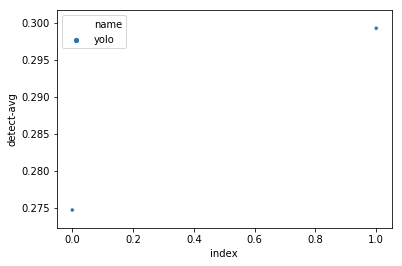

In [8]:
sns.scatterplot(data=data_ex,x='index',y='detect-avg',hue='name',size='name')

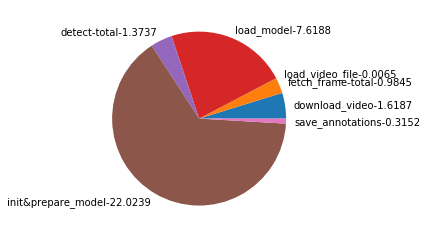

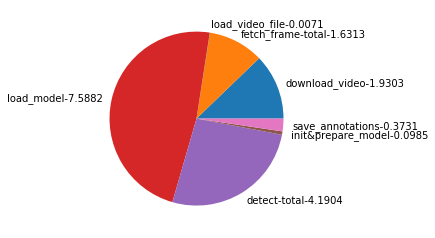

In [9]:
plot_pie_chart(data_ex,['name','index','input_file','Total_time','video_duration','video_file_size'])

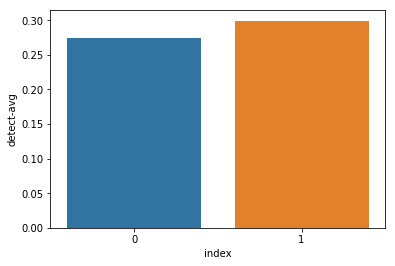

In [10]:
sns.barplot(x='index',y='detect-avg',data=data_ex)

In [23]:
v = list_detections(output_dict)
c,s = count_elems(v)
print(c['0'])

[1]


In [24]:
ints_ex['0']

[0.283937931060791,
 0.2739439010620117,
 0.27944397926330566,
 0.2633180618286133,
 0.2730839252471924]

In [19]:
output_dict['0']

{'Lane detection and object detection with OpenCV & TensorFlow-0040s.jpg': {'output': {'bounding_boxes': [[742,
     374,
     826,
     322]],
   'labels_detected': ['car']},
  'labels_matched': ['car'],
  'time': 0.2739369869232178}}